# OM3 Scaling

End-to-end pipeline generating scaling plots for [ACCESS-OM3 MC 25km JRA YF 2.0-beta configuration](https://github.com/ACCESS-NRI/access-om3-configs/releases/tag/release-MC_25km_jra_ryf-2.0-beta).

In [1]:
%load_ext autoreload
%autoreload 2

## Package versions

In [2]:
from importlib.metadata import version
for pkg in ("access.config.utils", "access.profiling",):
    print(f"{pkg}: {version(pkg)}")

access.config.utils: 0.3.dev7+g6230bd6c2
access.profiling: 0.2.dev27+g641b51c22.d20260914


## Setup
The following variables control where the configurations and model run outputs are saved.

In [57]:
## Imports
from pathlib import Path

from access.config.parallel_domain import Domain
from access.profiling.access_models import OM3Profiling, OM3_MC_25KM

test_path = f"/scratch/tm70/model_scaling/ACCESS-OM3/release-MC_25km_jra_ryf-2.0-beta"
archive_path = f"/g/data/tm70/model_scaling/ACCESS-OM3/release-MC_25km_jra_ryf-2.0-beta/archive"

om3_profiling = OM3Profiling(work_dir=Path(test_path), archive_dir=Path(archive_path), configuration=OM3_MC_25KM)
om3_profiling.set_control(repository="https://github.com/ACCESS-NRI/access-om3-configs.git", commit="release-MC_25km_jra_ryf-2.0-beta")

## Generate experiments

We will perform a simple scaling study, varying the total number of nodes used over `[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 8.0]`. We will search for different layouts that closely match a scaled 4-node released piControl config.

In [ ]:
# from access.config.parallel_allocation_strategies import RootAllocation, FreeAllocation, WholeRangeAllocation
from access.config.parallel_constraints import SubdomainAspectRatioConstraint, RankRatioGroupConstraint, MaxWastedCoreFractionConstraint, EqualCoresGroupConstraint

# Define how the cores should be allocated to the components
allocation_strategy = RootAllocation(
    subcomponents={
        "ocn": FreeAllocation(min_core_fraction=0.895,),
        "shared": FreeAllocation(min_core_fraction=0.095,
            subcomponents={
                "ice": WholeRangeAllocation(local_constraints=(SubdomainAspectRatioConstraint(max_ratio=1.05),),),
                "cpl": WholeRangeAllocation(),
                "rof": WholeRangeAllocation(),
                "atm": WholeRangeAllocation(),
            },
        ),
    },
    local_constraints=(MaxWastedCoreFractionConstraint(max_fraction=0.005),),
#        group_constraints=(
#        RankRatioGroupConstraint(name_a="ocn", name_b="shared", min_ratio=1),
#        RankRatioGroupConstraint(name_a="shared", name_b="ocn", min_ratio=1),
#    ),
)


from access.config.parallel_layouts import iter_layouts


layouts = list(iter_layouts(OM3_MC_25KM.parallel_component, 2*104, allocations=allocation_strategy))
print(len(layouts))
#for layout in iter_layouts(OM3_MC_25KM.parallel_component, 52, allocations=allocation_strategy):
for layout in layouts:
    print(layout.sub_layouts[1])
    print(layout.sub_layouts[0])
    print("\n")



In [17]:
# Generate the configuration and write to file
#num_nodes_list = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 8.0]
num_nodes_list = [1.0]
control_options = {
            "config.yaml": {
                "modules": {
                    "use": ["/g/data/vk83/prerelease/modules"],
                    "load": ["access-esm1p6/pr221-2"],
                },
                "manifest": {"reproduce": {"exe": False}},
                "postscript": "REMOVE",
            }
}

def walltime(num_nodes):
    return 2.5 * 4.0/num_nodes # use a 2.5 hrs time for 4-node runs, and then scale linearly

esm_profiling.generate_scaling_experiments(num_nodes_list=num_nodes_list, control_options=control_options, cores_per_node=104, walltime=walltime, allocations=allocation_strategy)

ValueError: FreeAllocation: unknown component names in allocations at root.shared: {'sea_ice'}. Valid names: {'ice', 'rof', 'atm', 'cpl'}.

## Run experiments

Next we run the experiments

In [6]:
esm_profiling.run_experiments()

## Parsing and plotting experiment results

In [7]:
from access.profiling.metrics import tmax

# Parse the data
esm_profiling.parse_profiling_data()

# Get the best (fastest) layouts for each node count
best_experiments = esm_profiling.select_best_experiments(component="payu",region="payu_model_run_duration_seconds", metric=tmax)
best_experiments

['esm1p6-layout_atm_8x6_mom_8x6_ice_8x1',
 'esm1p6-layout_atm_12x8_mom_12x8_ice_15x1',
 'esm1p6-layout_atm_14x11_mom_15x10_ice_8x1',
 'esm1p6-layout_atm_16x13_mom_17x12_ice_4x1',
 'esm1p6-layout_atm_20x13_mom_18x14_ice_8x1',
 'esm1p6-layout_atm_20x16_mom_21x14_ice_10x1',
 'esm1p6-layout_atm_24x17_mom_24x17_ice_10x1']

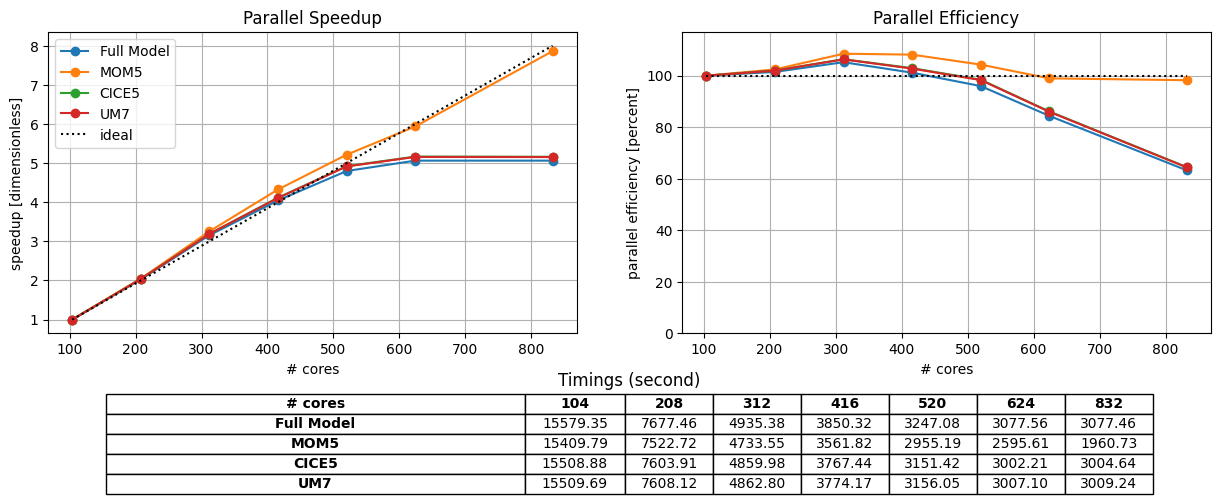

In [8]:
# Plot the scaling data, using only the best experiments
fig = esm_profiling.plot_scaling_data(
    components=["payu", "MOM5", "CICE5", "UM_Total_Walltime"],
    regions=[
        ["payu_model_run_duration_seconds"],
        ["Ocean"],
        ["Total"],
        ["um_total_walltime"],
    ],
    metric=tmax,
    region_relabel_map={
        "payu_model_run_duration_seconds": "Full Model",
        "Ocean": "MOM5",
        "Total": "CICE5",
        "um_total_walltime": "UM7",
    },
    experiments=best_experiments,
    xlabel="# cores",
)

## Summary

We have presented the strong scaling results for the [piControl v2.0 configuration](https://github.com/ACCESS-NRI/access-esm1.6-configs/releases/tag/release-piControl-2.0) of ESM 1.6. The underlying components are UM7.3 for atmosphere, MOM5 for ocean, and CICE5 for the ice models. These three components run concurrently over the course of the experiment, with the atmosphere and ice cores responsible for exchanging data (i.e., MPI operations between all three components). The released configuration for ESM1.6 uses 5-nodes on the normalsr queue with sapphirerapids cpus, where each node contains 104 cores.

We have varied the number of nodes between 1 and 8, and for each case, we have tested several options with different partitioning of the total number of available cores between the three components. In the plots above, we have presented the best performing configuration for each case. For the two top plots, the x-axis is the total number of cores used in the configuration, and the y-axis is speedup relative to the single node config (left) and computational efficiency relative to the single node config (right). The plot on the left shows that the ESM1.6 model shows near-ideal scaling up to 4 nodes, and then performance drops off and plateaus for higher node-counts. We observe a similar effect in the computational efficiency as well - the efficiency is above 90% for all nodes up to 5, but then drops off for higher node counts. UM/CICE dominate the scaling results and it is to be expected that any code will plateau when the serial part (potentially from synchronisation) starts to dominate (Amdahl's law). In addition, due to the concurrent running of the three components, we expect that this drop-off is partially from imperfect loadbalancing, and further investigation is required to improve the scaling for running ESM1.6 on >= 6 nodes. The table shows the raw data from the runs corresponding to each of the components, and the overall model runtime. The columns represent 1, 2, 3, 4, 5, 6, and 8 node configs.

# Archive

Archive experiments.

In [9]:
esm_profiling.archive_experiments(exclude_files=[
        "*.nc", 
        "aiihca*",
    ])

Experiment at /g/data/tm70/model_scaling/ACCESS-ESM1.6/piControl-2.0/archive/esm1p6-layout_atm_22x14_mom_18x17_ice_9x1.tar.gz is already archived. Skipping archiving.
Experiment at /g/data/tm70/model_scaling/ACCESS-ESM1.6/piControl-2.0/archive/esm1p6-layout_atm_18x12_mom_15x13_ice_4x1.tar.gz is already archived. Skipping archiving.
Experiment at /g/data/tm70/model_scaling/ACCESS-ESM1.6/piControl-2.0/archive/esm1p6-layout_atm_18x12_mom_15x13_ice_3x1.tar.gz is already archived. Skipping archiving.
Experiment at /g/data/tm70/model_scaling/ACCESS-ESM1.6/piControl-2.0/archive/esm1p6-layout_atm_14x11_mom_14x10_ice_15x1.tar.gz is already archived. Skipping archiving.
Experiment at /g/data/tm70/model_scaling/ACCESS-ESM1.6/piControl-2.0/archive/esm1p6-layout_atm_22x19_mom_20x20_ice_6x1.tar.gz is already archived. Skipping archiving.
Experiment at /g/data/tm70/model_scaling/ACCESS-ESM1.6/piControl-2.0/archive/esm1p6-layout_atm_20x13_mom_19x13_ice_8x1.tar.gz is already archived. Skipping archivin